In [1]:
# cv2: OpenCV 라이브러리로, 실시간 컴퓨터 비전을 목적으로 한 프로그래밍 라이브러리
# numpy(NumPy): 행렬이나 대규모 다차원 배열을 쉽게 처리할 수 있도록 지원하는 라이브러리. 데이터 구조 외에도 수치 계산을 위해 효율적으로 구현된 기능을 제공
# torch: PyTorch. 딥러닝 및 텐서 연산을 위한 라이브러리. 인공지능 모델을 만들거나 불러와 추론하는 도구
# torchvision: 이미지 변환 및 전처리를 위한 torchvision의 transform 모듈
# deeplabv3_resnet101: 사전 학습된 DeepLabV3 모델. 이미지를 분류하도록 학습된 모델
# matplotlib: 파이썬 프로그래밍 언어 및 수학적 확장 NumPy 라이브러리를 활용한 플로팅 라이브러리로, 데이터 시각화 도구

import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt


print('슝=3')

슝=3


이미지 크기: (450, 800, 3)


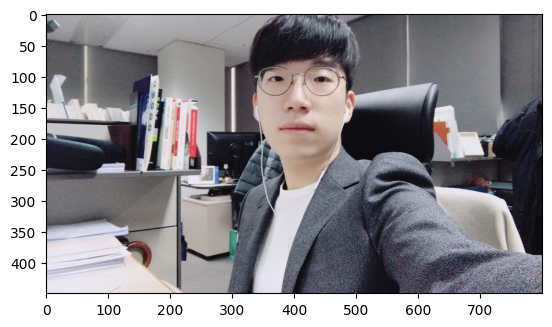

In [2]:
# 준비한 이미지 파일의 경로를 이용하여, 이미지 파일을 읽음
# cv2.imread(경로): 경로에 해당하는 이미지 파일을 읽어서 변수에 저장

img_path = os.path.join(os.getcwd(), '..', '..', 'work', 'human_segmentation', 'images', 'my_image.png')
img_orig = cv2.imread(img_path)

print(f"이미지 크기: {img_orig.shape}")

# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 이미지 색상 채널을 변경 (BGR 형식을 RGB 형식으로 변경)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시, 입력은 RGB(A) 데이터 혹은 2D 스칼라 데이터
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
# plt.show(): 현재 열려있는 모든 figure를 표시 (여기서 figure는 이미지, 그래프 등)
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

In [3]:
model = deeplabv3_resnet101(pretrained=True).eval()

/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

In [5]:
input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [6]:
%%time
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

CPU times: user 12.2 s, sys: 576 ms, total: 12.8 s
Wall time: 1.31 s


In [7]:
#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

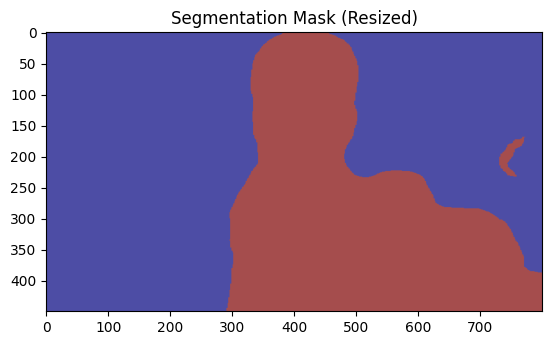

In [8]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [9]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0, 15], dtype=uint8)

In [10]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


In [11]:
# 아래 코드를 이해하지 않아도 좋습니다
# PixelLib에서 그대로 가져온 코드입니다
# 주목해야 할 것은 생성 코드 결과물이예요!

#컬러맵 만들기
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:20]  # 생성한 20개의 컬러맵 출력

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

In [12]:
colormap[15] #컬러맵 15에 해당하는 배열 출력 (pacalvoc에 LABEL_NAMES 15번째인 사람)

array([192, 128, 128])

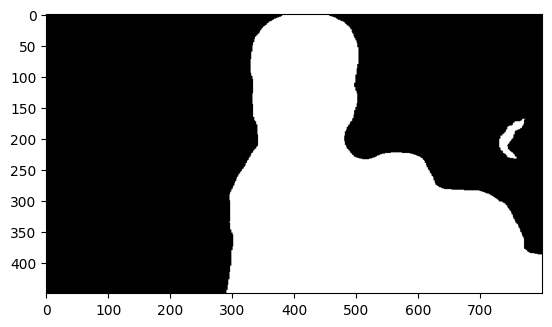

In [13]:
# output의 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False)이 됩니다
# 1과 0에 각각 255를 곱하였으므로 사람으로 예측된 픽셀은 255, 그렇지 않은 픽셀은 0
# cmap 값을 변경하면 다른 색상으로 확인이 가능함
seg_map = (output_predictions_resized == 15)  # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

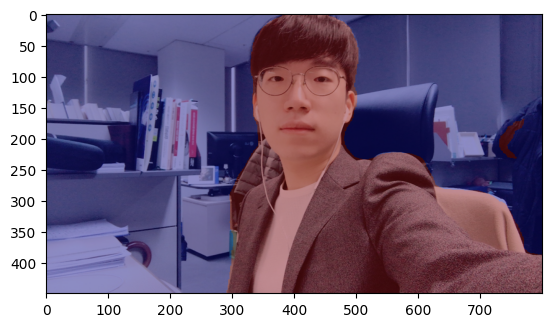

In [14]:
# 원본 이미지와 마스트를 적당히 합쳐봅니다
# 0.6과 0.4는 두 이미지를 섞는 비율입니다.

img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

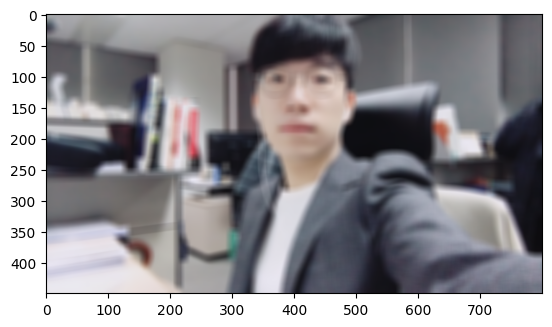

In [15]:
# (13,13)은 blurring kernel size를 뜻합니다
# 다양하게 바꿔보세요
img_orig_blur = cv2.blur(img_orig, (13, 13))

# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

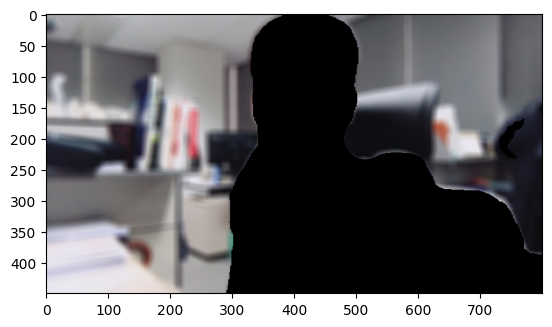

In [16]:
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지가 반전됩니다. 배경이 0 사람이 255 였으나
# 연산을 하고 나면 배경은 255 사람은 0입니다.
img_bg_mask = cv2.bitwise_not(img_mask_color)

# cv2.bitwise_and()을 사용하면 배경만 있는 영상을 얻을 수 있습니다.
# 0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에
# 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다. 결국 사람이 사라지고 배경만 남아요!
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

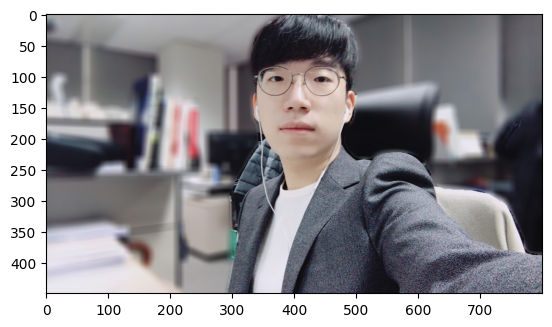

In [17]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

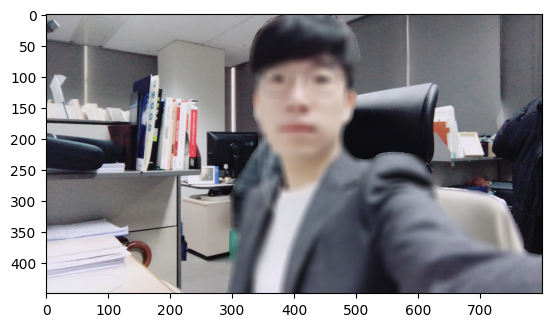

In [18]:
# Q. 이번에는 사람 부분을 블러로, 배경 부분을 원본으로 출력해볼까요?
# 힌트 : img_mask_color 옵션을 적절히 조정해주고, img_orig, img_orig_blur 를 활용하세요.
img_concat = np.where(img_mask_color == 255, img_orig_blur, img_orig)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

노드 2.인물사진을 만들어보자[프로젝트]

원본 고양이 이미지 크기: (1080, 1080, 3)
배경(사막) 이미지 크기: (900, 1200, 3)


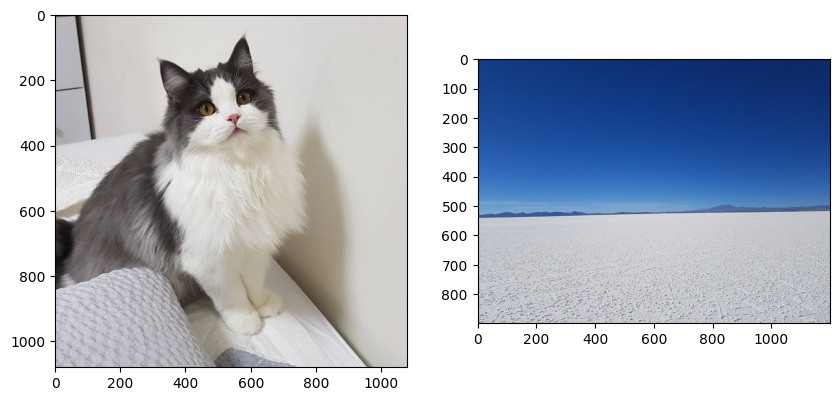

In [30]:

base_img_path = os.path.join(os.getcwd(), '..', '..', 'work', 'human_segmentation', 'images')
cat_img_path = os.path.join(base_img_path, 'scottish_straight_cat.jpg')  # 고양이 이미지를 준비해주세요
sand_img_path = os.path.join(base_img_path, "uyuni_salt _desert.jpg")  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [20]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [ ]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (1080, 1080)


In [22]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


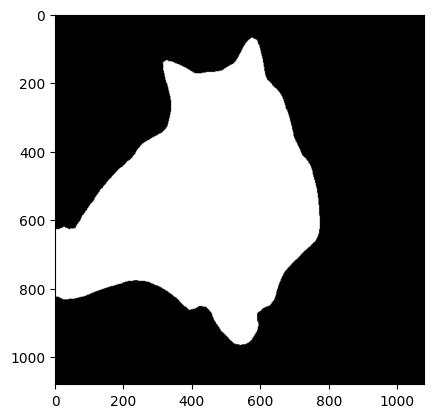

In [23]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

save_path = os.path.join(base_img_path, "cat_img_mask.png")
if not os.path.isfile(save_path):
    cv2.imwrite(save_path, img_mask)
    
plt.imshow(img_mask, cmap='gray')
plt.show()

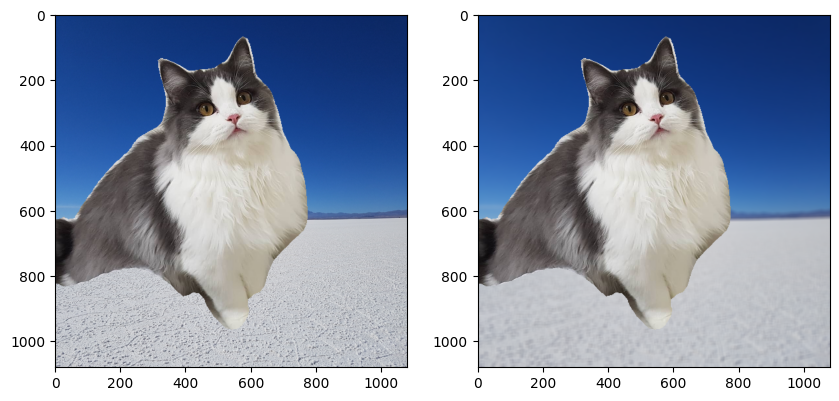

In [24]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

# bg blur
def bg_blur(img, bg_img, mask, target_color=255):
    if not img.shape == bg_img.shape:
        cv2.resize(bg_img, (img.shape[1], img.shape[0]))

    bg_mask_color = cv2.bitwise_not(cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR))
    bg_img_blur = cv2.blur(bg_img, (13, 13))
    img_bg_blur = cv2.bitwise_and(bg_img_blur, bg_mask_color)
    return np.where(img_mask_color==target_color, img, img_bg_blur)

result_img_bg_blur = bg_blur(cat_img, sand_img_resized, img_mask)


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(result_img)

plt.subplot(1, 2, 2)
plt.imshow(result_img_bg_blur)

plt.show()


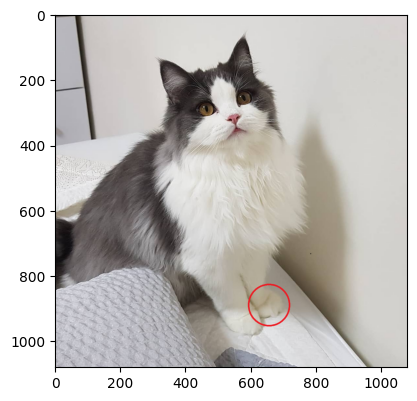

In [29]:
'''
    고양이 앞발 한쪽이 마스킹되지 않음
'''

base_img_path = os.path.join(os.getcwd(), '..', '..', 'work', 'human_segmentation', 'images')
cat_img_marked_path = os.path.join(base_img_path, 'scottish_straight_cat_marked.png')  # 고양이 이미지를 준비해주세요

cat_img_marked = cv2.imread(cat_img_marked_path)

cat_img_marked = cv2.cvtColor(cat_img_marked, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img_marked)

plt.show()

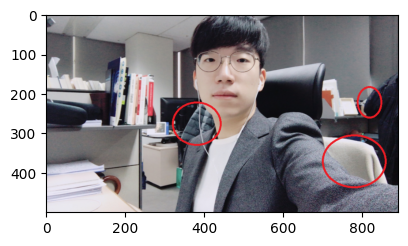

In [28]:
'''
    학습 노드에서 사람영역이 아닌 곳을 사람으로 판별함
'''

base_img_path = os.path.join(os.getcwd(), '..', '..', 'work', 'human_segmentation', 'images')
my_img_path = os.path.join(base_img_path, 'my_image_marked.png')  # 고양이 이미지를 준비해주세요

my_img_marked = cv2.imread(my_img_path)

my_img_marked = cv2.cvtColor(my_img_marked, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(my_img_marked)

plt.show()

보정 방법

원본 이미지를 토대로 심도 추정 모델을 이용해서 심도 맵을 추출한다.

추출된 심도맵을 grayscale 후 원본이미지에 블렌딩(덧셈 or 곱셈)을 수행한다.

블렌딩된 이미지를 deeplab v3모델에 넣어 segmentation을 수행한다.


-> 심도 추정 모델(Depth Anything Small) 로드 중...


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 3470.41it/s]


-> 심도 맵 생성 중 (CPU 연산)...
-> 심도 맵 추출 완료 및 저장 성공: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/Ex01/../../work/human_segmentation/images/scottish_straight_cat_depth_map.jpg


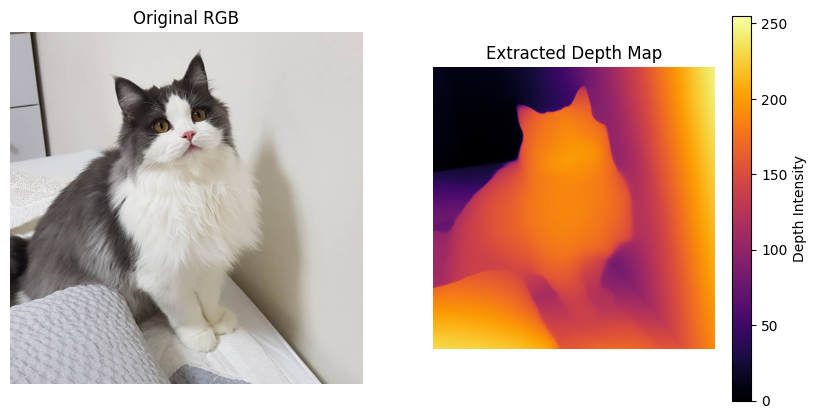

In [75]:

from PIL import Image
from transformers import pipeline

def extract_depth_map_only(image_path, save_path='extracted_depth_map.png'):
    """
    오직 원본 이미지로부터 Depth Anything 모델을 사용하여 
    0~255 범위의 그레이스케일 심도 맵만 추출하는 함수 (CPU 최적화)
    """
    # 1. 이미지 크기 확인을 위해 원본 로드
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {image_path}")
    h, w, _ = img.shape

    # 2. Depth Anything 파이프라인 로드 (명시적 CPU 지정)
    print("-> 심도 추정 모델(Depth Anything Small) 로드 중...")
    depth_estimator = pipeline(
        task="depth-estimation", 
        model="LiheYoung/depth-anything-small-hf",
        device="cpu"
    )
    
    # 3. 모델 추론 및 원본 크기로 리사이즈
    print("-> 심도 맵 생성 중 (CPU 연산)...")
    pil_img = Image.open(image_path)
    depth_outputs = depth_estimator(pil_img)
    
    # 4. 출력을 0~255 정수형 넘파이 배열로 변환
    depth_map = np.array(depth_outputs["depth"].resize((w, h))).astype(np.uint8)
    
    # 5. 파일로 저장
    cv2.imwrite(save_path, depth_map)
    print(f"-> 심도 맵 추출 완료 및 저장 성공: {save_path}")
    
    # 6. 노트북 확인용 주피터 시각화
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original RGB")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Extracted Depth Map")
    plt.imshow(depth_map, cmap='inferno') # 흑백으로 보고 싶다면 cmap='gray'
    plt.colorbar(label='Depth Intensity')
    plt.axis('off')
    plt.show()
    
    return depth_map
# 실행 예시 (경로를 본인 파일에 맞게 수정하여 사용하세요)
base_img_path = os.path.join(os.getcwd(), '..', '..', 'work', 'human_segmentation', 'images')
origin_img_name = 'scottish_straight_cat'
origin_path = os.path.join(base_img_path, f"{origin_img_name}.jpg") 
save_path =  os.path.join(base_img_path, f"{origin_img_name}_depth_map.jpg") 
depth_map = extract_depth_map_only(origin_path, save_path)

-> 심도 추정 모델(Depth Anything) 로드 중...


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 3670.16it/s]


-> 이미지 깊이 분석 중...
-> 고양이 검출 위치의 기준 초점 깊이: 165.00
-> 배경 노이즈가 제거된 정밀 마스크가 저장되었습니다.


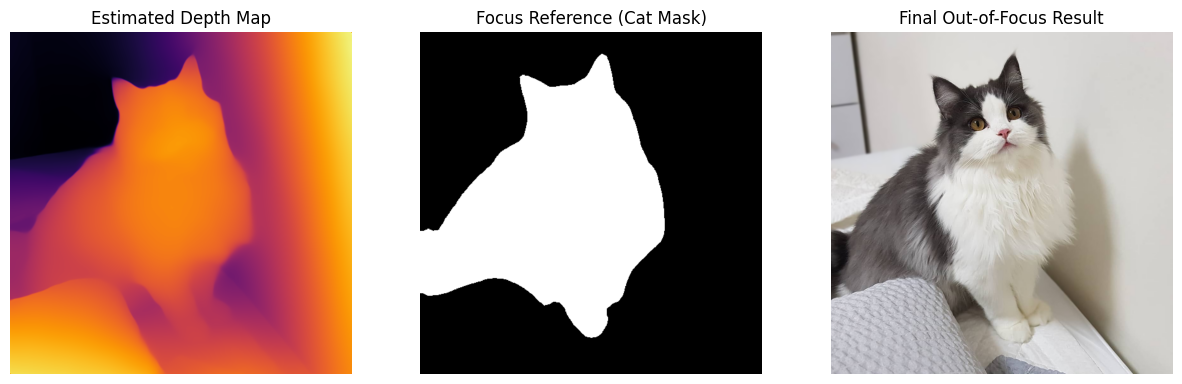

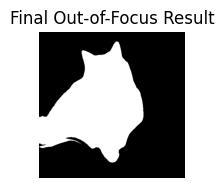

In [38]:
def apply_polarized_cat_mask(image_path, mask_path, output_mask_path='final_perfect_cat_mask.png'):
    """
    시그모이드 매핑으로 심도 맵을 양극화하고, 
    거리 제약 조건을 적용하여 고양이 앞발을 정밀 복원하는 함수
    """
    # 1. 이미지 및 기존 DeepLab 마스크 로드
    img = cv2.imread(image_path)
    h, w, _ = img.shape
    mask_raw = cv2.imread(mask_path, 0) # 0: IMREAD_GRAYSCALE
    mask = cv2.resize(mask_raw, (w, h), interpolation=cv2.INTER_NEAREST)

    # 2. Depth Anything 모델 로드 및 심도 추정 (CPU 모드)
    print("-> 심도 추정 모델(Depth Anything) 로드 중...")
    depth_estimator = pipeline(
        task="depth-estimation", 
        model="LiheYoung/depth-anything-small-hf",
        device="cpu"
    )
    
    print("-> 이미지 깊이 분석 중...")
    pil_img = Image.open(image_path)
    depth_outputs = depth_estimator(pil_img)
    depth_map = np.array(depth_outputs["depth"].resize((w, h))).astype(np.float32)

    # 3. 고양이 영역의 기준 초점 깊이(중앙값) 계산
    cat_pixels_depth = depth_map[mask > 0]
    if len(cat_pixels_depth) == 0:
        focus_depth = np.median(depth_map)
    else:
        focus_depth = np.median(cat_pixels_depth)

    # 4. [핵심] 시그모이드 매핑을 통한 심도 맵 양극화 (Contrast Stretching)
    # alpha 값이 클수록 고양이 경계면이 칼처럼 뚜렷하게 양극화됩니다.
    print("-> 심도 맵 시그모이드 양극화 적용 중...")
    alpha = 0.15 
    scaled_depth = depth_map - focus_depth
    sigmoid_depth = 1 / (1 + np.exp(-alpha * scaled_depth))
    polarized_depth_map = (sigmoid_depth * 255).astype(np.uint8)

    # 5. 양극화된 심도 맵에서 고양이 후보 영역(앞발 포함) 추출
    # 이미 흑백에 가깝게 양극화되었으므로 중간값(128)을 기준으로 타이트하게 슬라이싱합니다.
    # 고양이보다 앞에 있거나(초점 일치) 아주 살짝 뒤에 있는 영역까지 포함
    dof_mask = np.where(polarized_depth_map > 100, 255, 0).astype(np.uint8)

    # 6. [안전장치] 멀리 떨어진 배경 기둥 제거를 위한 거리 제약 조건 (Allowed Zone)
    # 기존 마스크를 사방으로 41픽셀 확장하여 '고양이 주변 버퍼 구역'을 생성합니다.
    buffer_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (41, 41))
    allowed_zone = cv2.dilate(mask, buffer_kernel, iterations=1)
    
    # 오직 고양이 몸체 주변 구역에 존재하는 심도 마스크만 유효한 앞발 영역으로 인정합니다.
    valid_paw_mask = cv2.bitwise_and(dof_mask, allowed_zone)

    # 7. 최종 병합 및 모폴로지 후처리
    # 기존 원본 마스크에 새롭게 구한 정밀 앞발 마스크를 합집합(OR) 합니다.
    final_corrected_mask = cv2.bitwise_or(mask, valid_paw_mask)
    
    # 외곽선 정돈 및 미세한 구멍 메우기
    closing_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    final_corrected_mask = cv2.morphologyEx(final_corrected_mask, cv2.MORPH_CLOSE, closing_kernel)

    # 8. 보정된 완성형 마스크 저장
    cv2.imwrite(output_mask_path, final_corrected_mask)
    print(f"-> 보정 완료! 완성형 마스크가 저장되었습니다: {output_mask_path}")

    # 9. 시각화 피드백 (양극화된 심도 맵과 최종 마스크 비교)
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 4, 1)
    plt.title("1. Original Depth Map")
    plt.imshow(depth_map, cmap='inferno')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("2. Polarized Depth Map (Sigmoid)")
    plt.imshow(polarized_depth_map, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("3. Original DeepLab Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("4. FINAL Corrected Mask (Perfect)")
    plt.imshow(final_corrected_mask, cmap='gray')
    plt.axis('off')

    plt.show()

    return final_corrected_mask

base_img_path = os.path.join(os.getcwd(), '..', '..', 'work', 'human_segmentation', 'images')
origin_path = os.path.join(base_img_path, 'scottish_straight_cat.jpg') 
mask_path =  os.path.join(base_img_path, 'cat_img_mask.png') 
apply_sophisticated_dof(origin_path, mask_path)

-> 심도 맵 리사이즈 완료: 1080 x 1080
-> 곱 블렌딩 리사이즈 완료: 1080 x 1080


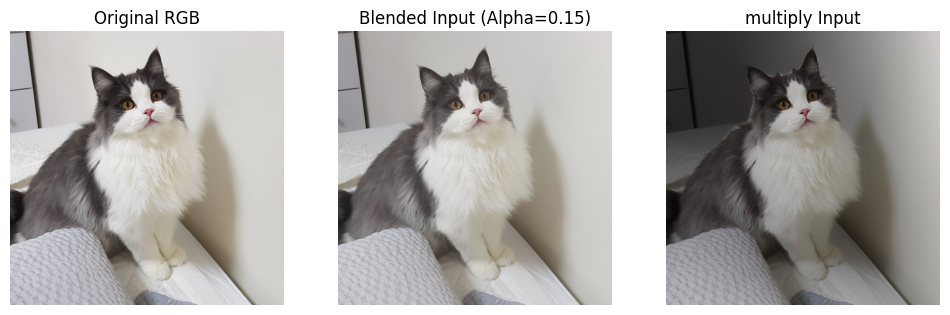

In [88]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def create_blended_input(image_path, depth_map, alpha=0.15, effect_strength=0.7):
    """
    image_path: 원본 고양이 이미지 경로
    depth_map: Depth Anything이 뱉은 2D 넘파이 배열 (0~255, 단일채널)
    alpha: 심도 맵을 얼마나 강하게 섞을지 결정 (0.0 ~ 1.0)
    """
    # 1. 원본 이미지 로드 및 크기 맞추기
    img = cv2.imread(image_path)
    h, w, _ = img.shape
    depth_resized = cv2.resize(depth_map, (w, h), interpolation=cv2.INTER_LINEAR)
    
    # 2. 단일 채널 심도 맵을 3채널(그레이스케일)로 확장
    depth_3ch = cv2.merge([depth_resized, depth_resized, depth_resized]).astype(np.uint8)
    print(f"-> 심도 맵 리사이즈 완료: {depth_resized.shape[1]} x {depth_resized.shape[0]}")

    img_float = img.astype(np.float32) / 255.0
    depth_float = depth_3ch.astype(np.float32) / 255.0
    multiplied = img_float * depth_float
    blended_float = (1.0 - effect_strength) * img_float + effect_strength * multiplied
    multi_blended = np.clip(blended_float * 255.0, 0, 255).astype(np.uint8)
    print(f"-> 곱 블렌딩 리사이즈 완료: {multi_blended.shape[1]} x {multi_blended.shape[0]}")
    
    # 3. 수식을 이용한 가중치 블렌딩 (RGB 이미지 + 심도 맵)
    # alpha 가 가중치입니다. 0.15 정도가 백본을 파괴하지 않는 안정적인 수치입니다.
    add_blended = cv2.addWeighted(img, 1 - alpha, depth_3ch, alpha, 0)
    
    # 4. 시각화 확인
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.title("Original RGB")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title(f"Blended Input (Alpha={alpha})")
    plt.imshow(cv2.cvtColor(add_blended, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"multiply Input")
    plt.imshow(cv2.cvtColor(multi_blended, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    
    # 이 blended_img를 기존 deeplab_model.predict()의 입력으로 그대로 사용합니다.
    return add_blended, multi_blended

# 실행 예시
add_blended, multi_blended = create_blended_input(cat_img_path, depth_map, alpha=0.15, effect_strength=0.8)
# output_mask = deeplab_model(mixed_input)

/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


추론 마스크 크기 (Before Resize): (520, 520)
추론 마스크 크기 (After Resize): (1080, 1080)
예측된 클래스 ID: [0 8]


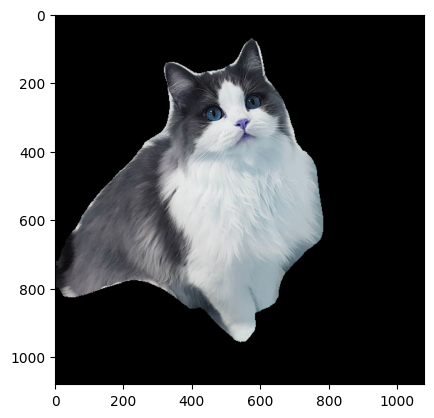

In [89]:
target_img = multi_blended.copy()
save_img_name = "cat_depth_result.jpg"

model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])
input_tensor = transform(target_img).unsqueeze(0)
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (target_img.shape[1], target_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

save_path = os.path.join(base_img_path, save_img_name)
origin_path = os.path.join(base_img_path, f"{origin_img_name}.jpg") 
origin_img = cv2.imread(origin_path)
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
img_mask = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)


final_img = cv2.bitwise_and(origin_img, img_mask)
if not os.path.isfile(save_path):
    cv2.imwrite(save_path, img_mask)
    
plt.imshow(final_img, cmap='gray')
plt.show()